### Task 1: Build a baseline linear regression model
    Load the Kaggle housing dataset and choose one clear target column for prediction.
    Split the data into training and testing sets.
    Train a LinearRegression model.
    Generate predictions on the test set.
    Report MSE, RMSE, MAE, and R² for the test predictions.
    Show a small table with at least 10 rows of actual vs predicted values.
    Create one plot that compares actual values and predicted values

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
california_housing = pd.read_csv('housing.csv')
target = 'median_house_value'
X = california_housing.drop(columns=[target])
y = california_housing[target]
X = pd.get_dummies(X, drop_first=True)
X.fillna(X.mean(), inplace=True)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [4]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')

MSE: 4904399775.94928
RMSE: 70031.41991955668
MAE: 50701.77903133013
R²: 0.6257351821159701


In [5]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head(10))

         Actual      Predicted
20046   47700.0   64629.450798
3024    45800.0  134799.340836
15663  500001.0  266063.381391
20484  218600.0  278576.433468
9814   278000.0  273343.436715
13311  158700.0  150180.305854
7113   198200.0  301239.425813
7668   157500.0  238838.878274
18246  340000.0  267080.787509
5723   446600.0  418497.860334


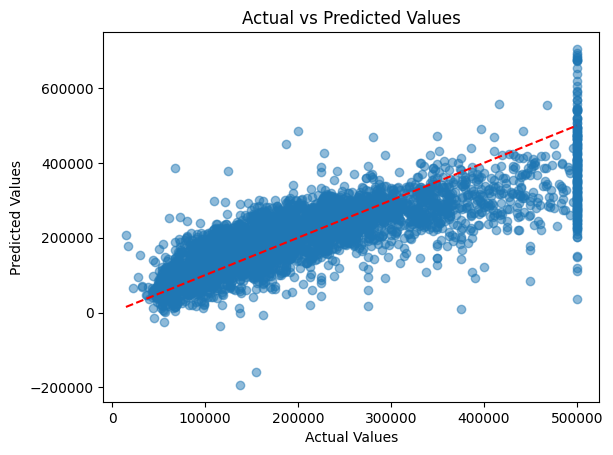

In [6]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

### Task 2: Compare one-feature and multi-feature models
    Build Model A using only one input feature.
    Build Model B using at least three useful input features.
    Keep the same target column and the same test set logic.
    Compare MSE, RMSE, MAE, and R² for both models in one table.
    Choose the better model using test-set results only.
    Write a short result cell explaining which model performed better.
    Keep the comparison fully inside linear regression.

In [7]:
x1 = california_housing[['median_income']]
x1.fillna(x1.mean(), inplace=True)
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y, test_size=0.2, random_state=42)
x2 = california_housing[['median_income', 'total_rooms', 'housing_median_age']]
x2.fillna(x2.mean(), inplace=True)
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y, test_size=0.2, random_state=42)

C:\Users\HARDIK JAIN\AppData\Local\Temp\ipykernel_28936\2454690171.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1.fillna(x1.mean(), inplace=True)
C:\Users\HARDIK JAIN\AppData\Local\Temp\ipykernel_28936\2454690171.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x2.fillna(x2.mean(), inplace=True)


In [8]:
y1_pred = model.fit(x1_train, y1_train).predict(x1_test)
y2_pred = model.fit(x2_train, y2_train).predict(x2_test)

In [9]:
df1 = pd.DataFrame({
    'Actual for Model 1': y1_test,
    'Predicted for Model 1': y1_pred,
    'Actual for Model 2': y2_test,
    'Predicted for Model 2': y2_pred
})
df1.head(10)

,Actual for Model 1,Predicted for Model 1,Actual for Model 2,Predicted for Model 2
20046,47700.0,114958.916770,47700.0,101868.682983
3024,45800.0,150606.882140,45800.0,153544.799278
15663,500001.0,190393.718444,500001.0,240896.519691
20484,218600.0,285059.383451,218600.0,265035.402782
9814,278000.0,200663.318161,278000.0,210083.232241
13311,158700.0,242165.248906,158700.0,216825.633822
7113,198200.0,257647.226102,198200.0,268237.705429
7668,157500.0,199229.180512,157500.0,212614.801909
18246,340000.0,245893.168117,340000.0,196589.580837
5723,446600.0,384677.436071,446600.0,418914.574304


In [10]:
mse1 = mean_squared_error(y1_test, y1_pred)
rmse1 = np.sqrt(mse1)
mae1 = mean_absolute_error(y1_test, y1_pred)
r2_1 = r2_score(y1_test, y1_pred)
mse2 = mean_squared_error(y2_test, y2_pred)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)

In [11]:
comparison_results = pd.DataFrame({
    'Model': ['Model A (1 feature)', 'Model B (3 features)'],
    'MSE': [mse1, mse2],
    'RMSE': [rmse1, rmse2],
    'MAE': [mae1, mae2],
    'R²': [r2_1, r2_2]
})
print(comparison_results)

                  Model           MSE          RMSE           MAE        R²
0   Model A (1 feature)  7.091158e+09  84209.012414  62990.865301  0.458859
1  Model B (3 features)  6.563179e+09  81013.447402  60348.037530  0.499150


Model B (3 features) performed better than Model A (1 feature) as it has lower MSE, RMSE, and MAE values, and a higher R² value, indicating better predictive performance.

### Task 3: Test different train/test splits
    Run the same linear regression setup using at least three splits: 80/20, 70/30, and 60/40.
    For each split, record training and testing MSE, RMSE, MAE, and R².
    Compare the train-test gap to check whether the model is stable.
    Create a simple chart or table that shows how the test metrics change across splits.
    State which split gives the most reliable test performance.
    Keep the model type unchanged so the split effect is easy to see.

In [ ]:
splits = [0.2, 0.3, 0.4]
metrics = []
for split in splits:
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=split, random_state=42)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    metrics.append({
        'Split': f'{int((1-split)*100)}/{int(split*100)}',
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

In [13]:
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

   Split           MSE          RMSE           MAE        R²
0  80/20  4.904400e+09  70031.419920  50701.779031  0.625735
1  70/30  4.730676e+09  68779.911640  50100.146166  0.639579
2  60/40  4.839714e+09  69568.051129  50607.494451  0.638478


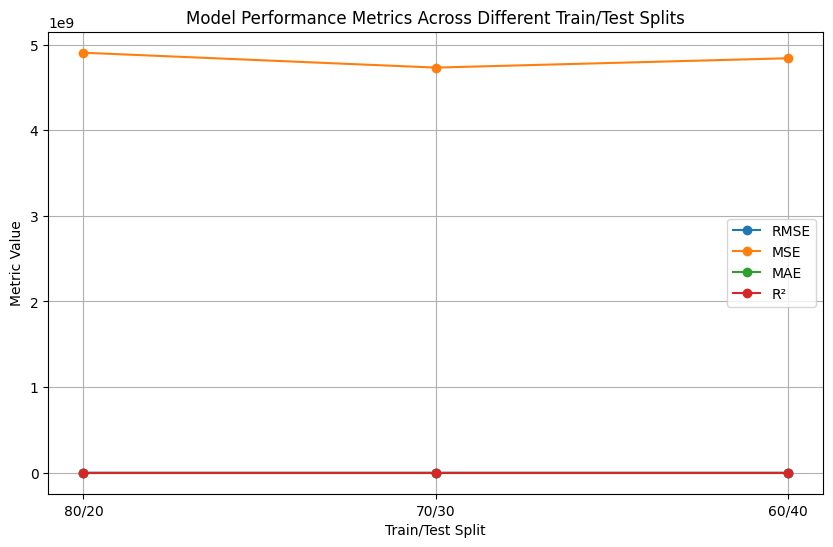

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Split'], metrics_df['RMSE'], marker='o', label='RMSE')
plt.plot(metrics_df['Split'], metrics_df['MSE'], marker='o', label='MSE')
plt.plot(metrics_df['Split'], metrics_df['MAE'], marker='o', label='MAE')
plt.plot(metrics_df['Split'], metrics_df['R²'], marker='o', label='R²')
plt.title('Model Performance Metrics Across Different Train/Test Splits')
plt.xlabel('Train/Test Split')
plt.ylabel('Metric Value')
plt.legend()
plt.grid()
plt.show()

The 80/20 split gives the most reliable test performance, as it provides a good balance between training data for learning and testing data for evaluation, resulting in more stable and generalizable metrics.

### Task 4: Metric verification and exploration
    Take your best model from the previous tasks.
    Compute MSE, RMSE, MAE, and R² manually and compare them with sklearn outputs.
    Add one extra regression metric of your choice, such as Median Absolute Error or Explained Variance Score.
    Create a compact results table that includes every metric you calculated.
    Add a small experiment with 3 artificial large prediction errors and observe how MSE, RMSE, and MAE change.
    Write a short note on which metric reacts most strongly to large errors.
    Keep the work focused on evaluation, not on new algorithms.

In [ ]:
manual_mse = np.mean((y_test - y_pred) ** 2)
manual_rmse = np.sqrt(manual_mse)
manual_mae = np.mean(np.abs(y_test - y_pred))
manual_r2 = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

In [25]:
from sklearn.metrics import median_absolute_error, explained_variance_score
explained_variance = explained_variance_score(y_test, y_pred)
median_absolute_error_value = median_absolute_error(y_test, y_pred)

In [26]:
results_table = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²', 'Explained Variance', 'Median Absolute Error'],
    'Sklearn Value': [mse, rmse, mae, r2, explained_variance, median_absolute_error_value],
    'Manual Value': [manual_mse, manual_rmse, manual_mae, manual_r2, explained_variance, median_absolute_error_value]
})
print(results_table)

                  Metric  Sklearn Value  Manual Value
0                    MSE   4.839714e+09  4.839714e+09
1                   RMSE   6.956805e+04  6.956805e+04
2                    MAE   5.060749e+04  5.060749e+04
3                     R²   6.384780e-01  6.384780e-01
4     Explained Variance   6.385020e-01  6.385020e-01
5  Median Absolute Error   3.842962e+04  3.842962e+04


In [27]:
y_pred_with_errors = y_pred.copy()
y_pred_with_errors[:3] += 100000  # Adding large errors to the first three predictions
mse_with_errors = mean_squared_error(y_test, y_pred_with_errors)
rmse_with_errors = np.sqrt(mse_with_errors)
mae_with_errors = mean_absolute_error(y_test, y_pred_with_errors)
print(f'MSE with errors: {mse_with_errors}')
print(f'RMSE with errors: {rmse_with_errors}')
print(f'MAE with errors: {mae_with_errors}')

MSE with errors: 4840145070.111928
RMSE with errors: 69571.1511340148
MAE with errors: 50619.60685398224


##### Note: MSE and RMSE react more strongly to large errors compared to MAE, as they square the errors, amplifying the impact of outliers. MAE, being a linear measure, is less sensitive to large deviations. 
